# Macroeconomic Early-Warning Measures for Systemic Risk

## Introduction

This notebook studies the macroeconomic measures presented in Appendix A of the Bisias et al. handbook on systemic risk. The broad aim of that appendix is to describe a class of methods designed to warn policymakers about the build-up of large-scale financial instability before a crisis fully materializes. Rather than focusing on the risk of a single institution, these measures look at aggregate indicators such as *credit growth*, *money growth*, and *asset-price* deviations from trend, with the goal of detecting system-wide imbalances.

At its core, this topic is about the following problem: given a candidate macro-financial indicator, how do we decide whether it is actually useful as a warning signal? The appendix approaches this by turning the problem into one of statistical classification. An indicator *issues a warning* when it crosses a threshold, and that warning can then be judged against what later happens in the economy. This creates the familiar possibilities of correct warnings, missed crises, and false alarms.

The notebook therefore aims to clarify not just the formulas, but the underlying logic. In particular, it explains how the authors define crises and warning signals, how they evaluate an indicator through a policymaker-weighted loss function, and why usefulness is measured relative to trivial benchmark rules such as “always signal” and “never signal.” The emphasis here is not merely on reproducing notation, but on making explicit the decision problem that the appendix is trying to formalize.

In short, this notebook treats Appendix A as an early-warning framework for systemic risk. Its purpose is to unpack how macroeconomic indicators are converted into warning rules, how those rules are scored, and how one decides whether an indicator contains genuine information or is no better than a naive signaling strategy.

**Reference**

Bisias, Dimitrios, et al. “A Survey of Systemic Risk Analytics.” *Annual Review of Financial Economics*, vol. 4, no. 1, 2012, pg 48–56 https://dspace.mit.edu/bitstream/handle/1721.1/87772/Lo_A%20survey.pdf?sequence=1&isAllowed=y.

# A Macroeconomic Measures

This section motivates the use of macroeconomic aggregates as tools for monitoring systemic risk. The central premise is that events severe enough to threaten financial stability should be visible at highly aggregated levels of the economy, such as asset prices, output, and public debt. Empirical work, particularly by Reinhart and Rogoff, shows that financial crises exhibit recurring patterns across countries and over time, suggesting that these aggregate variables contain meaningful signals of systemic imbalances.

The discussion emphasizes that such historical regularities can be used not only for descriptive purposes but also as a guide for policy. Aggregate indicators can help identify large-scale distortions and inform regulatory responses. In this context, macroeconomic monitoring is closely linked to macroprudential regulation, where policymakers track broad economic conditions to detect and mitigate the buildup of systemic vulnerabilities before they result in crises. Macroprudential refers to a regulatory approach that focuses on safeguarding the stability of the financial system as a whole, rather than individual institutions, by monitoring and mitigating system-wide risks.

Overall, the goal of this section is to justify why macro-level data provide a valid and practical starting point for constructing early-warning measures of systemic risk.

## A.1 Costly Asset-Price Boom/Bust Cycles

This section introduces the empirical framework of Alessi and Detken (2009), which applies a signaling methodology to predict costly aggregate asset-price boom–bust cycles. The focus is on evaluating a broad set of real and financial variables as potential early-warning indicators, using data from 18 OECD countries over the period 1970–2007.

The approach treats each variable as a candidate signal that can forecast whether an asset-price boom with significant real economic consequences is likely to occur. Rather than relying on a single indicator, the objective is to compare many alternatives and assess their relative performance.

To do so, the authors introduce a policymaker-oriented loss function that ranks indicators according to preferences over missed crises and false alarms. This allows the evaluation to reflect policy trade-offs, rather than purely statistical accuracy. The analysis then examines how different categories of indicators—such as financial versus real variables, global versus domestic measures, and money- versus credit-based liquidity indicators—perform within this framework.

### A.1.1 Definition

This section develops a full empirical framework for evaluating early-warning indicators of costly asset-price boom–bust cycles. The starting point is a classification setup: each indicator, together with a threshold, produces a binary signal (issue warning or not), and its performance is evaluated using the confusion matrix $(A,B,C,D)$, corresponding to correct signals, false alarms, missed crises, and correct non-signals.

The evaluation is driven by the policymaker-weighted loss function
$$
L = \theta \frac{C}{A+C} + (1-\theta)\frac{B}{B+D},
$$
which reflects the trade-off between Type I errors (missed crises) and Type II errors (false alarms). The loss function also provides a natural benchmark for evaluating whether an indicator is useful at all. To see this, consider two trivial signaling rules. The first is to always issue a warning, regardless of the data. In this case, there are no missed crises ($C=0$), but all non-crisis periods generate false alarms, so the loss reduces to $1-\theta$. The second is to never issue a warning. In this case, there are no false alarms ($B=0$), but all crises are missed, so the loss is $\theta$.

These two rules represent baseline strategies that do not use any information from the indicator. Therefore, any nontrivial indicator—i.e. one that produces its own $(A,B,C,D)$ through a threshold rule—must be evaluated relative to these benchmarks. The best outcome achievable without using the indicator is $\min\{\theta, 1-\theta\}$, obtained by choosing whichever trivial rule yields the lower loss.

An indicator is thus considered useful only if its loss $L$ is strictly lower than this benchmark. In other words, the indicator must improve upon both trivial strategies by producing a more favorable balance between missed crises and false alarms, given the policymaker’s preference parameter $\theta$.

To apply this framework, the authors define the underlying events of interest. An **aggregate asset-price boom** is identified as a period of at least three consecutive quarters during which a real asset price index exceeds a recursively estimated trend by 1.75 times its standard deviation. The trend is computed using a one-sided Hodrick–Prescott filter with a very high smoothing parameter ($\lambda = 100{,}000$), ensuring that only persistent deviations are classified as booms.

The authors further distinguish between benign and harmful booms. A **high-cost boom (HCB)** is defined as a boom followed by a three-year period of GDP growth that falls significantly below potential. This distinction is crucial, as the goal is not to predict all booms, but specifically those that lead to meaningful real economic damage. In the sample, 45 booms are identified, of which 29 are classified as high-cost and 16 as low-cost.

The empirical analysis is conducted using data from 18 OECD countries over the period 1970–2007. A large set of candidate indicators is considered, spanning real economic variables, financial variables, and global aggregates, as summarized in Table A.2. These include GDP components, inflation, interest rates, asset prices, exchange rates, and monetary and credit aggregates. Some variables, particularly money and credit growth, are further adjusted using recursive VAR models to remove endogenous business-cycle and asset-price components.

Threshold selection is handled through a grid search over percentiles of each indicator’s distribution. Two approaches are considered. In the **individual-country case**, thresholds are optimized separately for each country and indicator. In the **individual-indicator case**, a common threshold is chosen across countries to minimize aggregate loss. In both cases, thresholds are applied dynamically as the distribution of the indicator evolves over time.

In addition to the usefulness measure derived from the loss function, the framework also reports auxiliary performance metrics. These include the true positive rate $tp = \frac{A}{A+B}$, the true negative rate $tn = \frac{D}{C+D}$, the difference between conditional and unconditional probabilities of events, and the average lead time (ALT), which measures how early a signal is issued before the onset of a crisis.

Overall, the section provides a complete procedure for constructing, evaluating, and comparing early-warning indicators. It combines a precise definition of economically meaningful boom–bust events with a policymaker-oriented loss function and a systematic threshold-selection process, yielding a framework in which indicators can be ranked according to their practical usefulness in signaling costly financial imbalances.

### A.1.2. Inputs and Outputs

This section formalizes the computational setup of the signaling framework by specifying the required inputs and the resulting outputs. The goal is to operationalize the evaluation of indicators in a consistent and reproducible way.

**Inputs**

1. **Indicator time series**  
   Quarterly data (1970:Q1–2007:Q4) for each of 18 OECD countries. Each indicator is a **time-indexed vector of floats**. Most series are seasonally adjusted, and some (e.g., money and credit growth) are further processed via recursive VAR models to remove endogenous components. A one-quarter publication lag is imposed, so signals at time $t$ use data up to $t-1$.

2. **Policymaker preference parameter $\theta$**  
   A **scalar float in $[0,1]$** representing the relative weight placed on missed crises (Type I errors) versus false alarms (Type II errors). The analysis is performed for multiple values (e.g., 0.2–0.8) to reflect different policy preferences.

---

**Outputs**

1. **Confusion matrix counts $(A,B,C,D)$**  
   **Integers** representing frequencies of correct signals, false alarms, missed crises, and correct non-signals.

2. **True positive and true negative rates**  
   - $tp = \frac{A}{A+B}$  
   - $tn = \frac{D}{C+D}$  
   Both are **floats in $[0,1]$**, measuring detection accuracy.

3. **Usefulness measure**  
   $\min\{\theta,1-\theta\} - L$ is a **float**, representing how much the indicator improves upon the best trivial rule. A positive value indicates that the indicator is informative.

4. **Probability difference $dp$**  
   A **float** measuring the difference between the conditional probability of a crisis given a signal and the unconditional probability. It captures how informative a signal is in probabilistic terms.

5. **Average lead time (ALT)**  
   A **float** representing the average number of quarters by which a signal precedes the onset of a crisis.

---

Overall, the objective is to map raw macroeconomic data into a set of quantitative metrics that allow indicators to be systematically compared and ranked based on their usefulness in signaling costly boom–bust cycles.

### A.1.3 Empirical Findings

This section reports the empirical performance of the signaling framework and identifies which indicators are most effective in predicting high-cost asset-price boom–bust cycles.

The main result is that **global liquidity measures**, in particular the global M1 gap and the global private credit gap, emerge as the best early-warning indicators. This suggests that asset-price boom–bust cycles are largely **international phenomena**, and that global variables contain more predictive information than purely domestic ones.

The effectiveness of indicators depends on the policymaker preference parameter $\theta$. When preferences between missed crises and false alarms are relatively balanced, the best indicators can reduce the weighted sum of errors by up to about 25% compared to ignoring the indicator entirely. However, when policymakers strongly prefer one type of error over the other, the improvement becomes less pronounced.

In terms of specific performance, the global private credit gap—using an optimal threshold around the 70th percentile—achieves a high true positive rate (around 82%) and provides early warnings with an average lead time of approximately 5.5 quarters.

More broadly, the findings indicate that:
- financial indicators outperform real economic variables,
- global indicators outperform domestic ones, and
- credit-based measures outperform money-based measures.

Finally, the section notes that the signaling methodology builds on earlier work (e.g., Kaminsky, Lizondo, and Reinhart), with the main difference being the use of the policymaker-based usefulness measure instead of the traditional signal-to-noise ratio.

## Example Replication

So far, the discussion has been conceptual: we have clarified what the signaling framework is trying to do, how the loss function works, why trivial rules such as “always signal” and “never signal” matter, and how usefulness is defined relative to those baselines. The next step is to make these ideas concrete by implementing a simplified version of the framework in code.

Because the original paper uses a large historical macroeconomic panel, we begin with **synthetic data** instead. The purpose of using synthetic data is not to reproduce the empirical findings of the paper exactly, but to create a controlled setting in which the logic of the model can be seen clearly. In particular, synthetic data allow us to specify by construction when a “costly boom/bust cycle” occurs, so that we know the ground truth and can directly study how the signaling methodology behaves.

The plan is as follows. We will generate an artificial macro-financial indicator together with an artificial crisis variable. We then define a signaling rule: a warning is issued whenever the indicator exceeds a chosen percentile threshold of its own distribution. From this rule we compute the confusion matrix $(A,B,C,D)$, the policymaker-weighted loss function
$$
L = \theta \frac{C}{A+C} + (1-\theta)\frac{B}{B+D},
$$
and the usefulness measure
$$
\min\{\theta,1-\theta\} - L.
$$
We will also compute auxiliary quantities such as the true positive rate, true negative rate, and average lead time. In this way, the code will illustrate exactly what the framework is doing and why.

In [2]:
import numpy as np
import pandas as pd

# ==========================================
# SYNTHETIC DATA
# ==========================================
# We create synthetic data because the original paper uses a large historical
# macroeconomic panel, which is unnecessary for first understanding the logic.
# Here we generate an artificial indicator and an artificial crisis label so
# that we know the "truth" by construction and can see clearly how the
# signaling methodology behaves.

np.random.seed(42)

n = 160  # number of quarters
dates = pd.period_range(start="1980Q1", periods=n, freq="Q")

# Synthetic macro-financial indicator:
# a smooth cycle + noise + several elevated periods that are meant to mimic
# the buildup toward costly boom/bust episodes.
base = 0.8 * np.sin(np.linspace(0, 10*np.pi, n))
noise = 0.35 * np.random.randn(n)
indicator = base + noise

# Inject a few persistent "boom" regimes
boom_windows = [(30, 36), (72, 78), (115, 122)]
for s, e in boom_windows:
    indicator[s:e] += 1.5

# Synthetic costly boom/bust event label:
# event_t = 1 means a costly boom/bust cycle occurs within the next 6 quarters.
# We mark the run-up period before each boom window as a period where an early
# warning would be considered correct.
event = np.zeros(n, dtype=int)
horizon = 6
for s, e in boom_windows:
    start_warn = max(0, s - horizon)
    event[start_warn:s] = 1

df = pd.DataFrame({
    "date": dates.astype(str),
    "indicator": indicator,
    "event_within_6q": event
})

# ==========================================
# SIGNALING RULE
# ==========================================
def make_signal(x, percentile):
    """
    Issue a signal when the indicator exceeds the chosen percentile
    of its own distribution.

    Inputs
    ------
    x : 1D array-like of floats
        Candidate indicator series.
    percentile : float
        Threshold percentile in [0,1], e.g. 0.7 for the 70th percentile.

    Output
    ------
    signal : 1D integer array (0/1)
        1 if warning is issued, 0 otherwise.
    """
    thr = np.quantile(x, percentile)
    return (x > thr).astype(int), thr

# ==========================================
# CONFUSION MATRIX
# ==========================================
def confusion_counts(signal, event):
    """
    Compute A, B, C, D using the paper's convention:
    A = signal issued and event occurs
    B = signal issued and no event occurs
    C = no signal and event occurs
    D = no signal and no event occurs
    """
    signal = np.asarray(signal, dtype=int)
    event = np.asarray(event, dtype=int)

    A = int(np.sum((signal == 1) & (event == 1)))
    B = int(np.sum((signal == 1) & (event == 0)))
    C = int(np.sum((signal == 0) & (event == 1)))
    D = int(np.sum((signal == 0) & (event == 0)))
    return A, B, C, D

# ==========================================
# LOSS AND USEFULNESS
# ==========================================
def safe_div(num, den):
    return np.nan if den == 0 else num / den

def loss_function(A, B, C, D, theta):
    """
    L = theta * C/(A+C) + (1-theta) * B/(B+D)
    """
    type1 = safe_div(C, A + C)  # missed-crisis rate
    type2 = safe_div(B, B + D)  # false-alarm rate
    return theta * type1 + (1 - theta) * type2

def usefulness(A, B, C, D, theta):
    """
    usefulness = min(theta, 1-theta) - L
    """
    L = loss_function(A, B, C, D, theta)
    return min(theta, 1 - theta) - L

# ==========================================
# AUXILIARY METRICS
# ==========================================
def true_positive_rate(A, B):
    return safe_div(A, A + B)

def true_negative_rate(C, D):
    return safe_div(D, C + D)

def dp_metric(A, B, C, D):
    """
    Difference between conditional and unconditional event probabilities:
    dp = A/(A+B) - (A+C)/(A+B+C+D)
    """
    cond = safe_div(A, A + B)
    uncond = safe_div(A + C, A + B + C + D)
    return cond - uncond

def average_lead_time(signal, event):
    """
    Crude synthetic version of average lead time:
    For each event block, find the first signal before or at the start of the event block,
    and count how many quarters in advance it occurred.
    """
    signal = np.asarray(signal, dtype=int)
    event = np.asarray(event, dtype=int)

    leads = []
    in_block = False
    starts = []

    for i in range(len(event)):
        if event[i] == 1 and not in_block:
            starts.append(i)
            in_block = True
        elif event[i] == 0 and in_block:
            in_block = False

    for s in starts:
        prev_signals = np.where(signal[:s+1] == 1)[0]
        if len(prev_signals) > 0:
            first_relevant = prev_signals[-1]
            leads.append(s - first_relevant)

    return np.nan if len(leads) == 0 else float(np.mean(leads))

# ==========================================
# THREE SIGNALING RULES
# ==========================================
theta = 0.5
percentile = 0.70

# 1) Nontrivial indicator-based rule
sig_ind, thr = make_signal(df["indicator"].values, percentile)
A, B, C, D = confusion_counts(sig_ind, df["event_within_6q"].values)

# 2) Always signal
sig_always = np.ones(n, dtype=int)
A_a, B_a, C_a, D_a = confusion_counts(sig_always, df["event_within_6q"].values)

# 3) Never signal
sig_never = np.zeros(n, dtype=int)
A_n, B_n, C_n, D_n = confusion_counts(sig_never, df["event_within_6q"].values)

# ==========================================
# RESULTS
# ==========================================
results = pd.DataFrame([
    {
        "rule": "indicator",
        "threshold_percentile": percentile,
        "threshold_value": thr,
        "A": A, "B": B, "C": C, "D": D,
        "L": loss_function(A, B, C, D, theta),
        "usefulness": usefulness(A, B, C, D, theta),
        "tp": true_positive_rate(A, B),
        "tn": true_negative_rate(C, D),
        "dp": dp_metric(A, B, C, D),
        "ALT": average_lead_time(sig_ind, df["event_within_6q"].values)
    },
    {
        "rule": "always_signal",
        "threshold_percentile": np.nan,
        "threshold_value": np.nan,
        "A": A_a, "B": B_a, "C": C_a, "D": D_a,
        "L": loss_function(A_a, B_a, C_a, D_a, theta),
        "usefulness": usefulness(A_a, B_a, C_a, D_a, theta),
        "tp": true_positive_rate(A_a, B_a),
        "tn": true_negative_rate(C_a, D_a),
        "dp": dp_metric(A_a, B_a, C_a, D_a),
        "ALT": average_lead_time(sig_always, df["event_within_6q"].values)
    },
    {
        "rule": "never_signal",
        "threshold_percentile": np.nan,
        "threshold_value": np.nan,
        "A": A_n, "B": B_n, "C": C_n, "D": D_n,
        "L": loss_function(A_n, B_n, C_n, D_n, theta),
        "usefulness": usefulness(A_n, B_n, C_n, D_n, theta),
        "tp": true_positive_rate(A_n, B_n),
        "tn": true_negative_rate(C_n, D_n),
        "dp": dp_metric(A_n, B_n, C_n, D_n),
        "ALT": average_lead_time(sig_never, df["event_within_6q"].values)
    }
])

In [3]:
print("Synthetic data preview:")
df.head()

Synthetic data preview:


,date,indicator,event_within_6q
0,1980Q1,0.173850,0
1,1980Q2,0.108649,0
2,1980Q3,0.534662,0
3,1980Q4,0.979978,0
4,1981Q1,0.486519,0


In [4]:
df.tail()

,date,indicator,event_within_6q
155,2018Q4,-0.818496,0
156,2019Q1,0.206104,0
157,2019Q2,-0.142130,0
158,2019Q3,-0.573997,0
159,2019Q4,0.229794,0


In [6]:
print("\nResults:")
results.round(4)


Results:


,rule,threshold_percentile,threshold_value,A,B,C,D,L,usefulness,tp,tn,dp,ALT
0,indicator,0.7,0.5686,5,43,13,99,0.5125,-0.0125,0.1042,0.8839,-0.0083,4.6667
1,always_signal,NaN,NaN,18,142,0,0,0.5000,0.0000,0.1125,NaN,0.0000,0.0000
2,never_signal,NaN,NaN,0,0,18,142,0.5000,0.0000,NaN,0.8875,NaN,NaN


### Interpretation of Signaling Results

The results show that the indicator-based rule does not outperform the trivial benchmarks under the chosen threshold. Specifically, the loss for the indicator is $L = 0.5125$, which is slightly higher than the benchmark value $\min\{\theta,1-\theta\} = 0.5$, yielding a negative usefulness of $-0.0125$. This means that, under this specification, the indicator performs worse than simply always signaling or never signaling.

Comparing across the three rules makes this clear. The “always signal” rule produces no missed crises ($C=0$) but many false alarms, while the “never signal” rule produces no false alarms ($B=0$) but misses all crises. Both yield the same loss of $0.5$ when $\theta=0.5$, establishing the baseline.

The indicator rule sits between these extremes: it detects some crises ($A=5$) but still misses many ($C=13$), while also generating a substantial number of false alarms ($B=43$). As a result, it fails to improve upon the trivial strategies.

The auxiliary metrics reinforce this conclusion. The true positive rate is low ($tp \approx 0.10$), meaning only about 10% of crises are correctly predicted, while the true negative rate is high ($tn \approx 0.88$), indicating that non-crisis periods are mostly correctly identified. The negative $dp$ further suggests that the signal does not meaningfully increase the probability of a crisis conditional on a warning.

The only positive aspect is the average lead time (ALT ≈ 4.7 quarters), indicating that when signals do occur, they tend to precede events by a reasonable margin. However, given the poor classification performance overall, this alone is not sufficient to make the indicator useful.

Overall, this example illustrates an important point: not every indicator, even if intuitively reasonable, provides meaningful predictive value. The loss-function framework makes this explicit by comparing performance against trivial benchmarks.

---

**The A.1 Framework: Evaluation of Early-Warning Indicators, how they are used**

The A.1 framework provides a **method for evaluating the usefulness of a signaling rule**. It does not prescribe how signals are constructed; instead, it takes a given signal as input and assesses its performance.

The input to the framework is a **binary signal** (0/1), typically generated by applying a threshold to an indicator, together with a **realized event series** (e.g., occurrence of a crisis). From these, the framework computes the confusion matrix $(A,B,C,D)$, representing correct signals, false alarms, missed crises, and correct non-signals.

The core evaluation metric is the policymaker-weighted loss function
$$
L = \theta \frac{C}{A+C} + (1-\theta)\frac{B}{B+D},
$$
where $\theta \in [0,1]$ reflects the relative importance placed on missed crises versus false alarms. The performance of the signal is then compared against two trivial benchmark rules—“always signal” and “never signal”—which yield losses $1-\theta$ and $\theta$, respectively.

The key output is the **usefulness measure**
$$
\min\{\theta,1-\theta\} - L,
$$
which quantifies whether the signal improves upon these trivial strategies. A positive value indicates that the signal contains meaningful predictive information. Additional outputs such as true positive rate, true negative rate, and average lead time provide further diagnostics.

Overall, A.1 is a **general evaluation framework**: given any signaling rule, it determines how effective that rule is in predicting costly events.

---

**How Signals Are Combined in A.1**

In the A.1 framework, there is no restriction on how a signal is constructed. The framework only requires a **binary signal** as input. Therefore, signals from multiple indicators can be combined in any way before being evaluated.

The simplest case is a single-indicator rule:
$$
S_t = \mathbf{1}\{\text{indicator}_t > c\}.
$$

However, one can also define combined signals using multiple indicators. For example:

- **Conjunctive (AND) rule**:
$$
S_t = \mathbf{1}\{\text{indicator}_1 > c_1 \ \text{and} \ \text{indicator}_2 > c_2\}.
$$

- **Disjunctive (OR) rule**:
$$
S_t = \mathbf{1}\{\text{indicator}_1 > c_1 \ \text{or} \ \text{indicator}_2 > c_2\}.
$$

- **Weighted or composite rule**:
$$
S_t = \mathbf{1}\{w_1 \cdot \text{indicator}_1 + w_2 \cdot \text{indicator}_2 > c\}.
$$

Each such construction defines a different signaling rule. Once the signal $S_t$ is defined, it is evaluated using the same procedure:
- compute $(A,B,C,D)$,
- compute the loss $L$,
- compare against $\min\{\theta,1-\theta\}$.

Thus, A.1 does not prescribe how to combine indicators—it simply evaluates the resulting signal. In this sense, it is **agnostic to model structure**: any combination rule can be tested within the same loss-based framework.

---

## A.2 Property-Price, Equity-Price, and Credit-Gap Indicators

This section introduces an alternative macroeconomic early-warning framework based on property-price, equity-price, and credit-gap indicators, following Borio (2009) and related work. The central idea is grounded in the endogenous-cycle view of financial instability: periods of unusually rapid credit growth combined with elevated asset prices signal the buildup of financial imbalances that increase the likelihood of future distress.

Rather than evaluating indicators individually as in the previous section, this approach emphasizes **joint signals**. Specifically, warnings are issued when combinations of indicators simultaneously exceed their respective thresholds, capturing the interaction between credit expansion and asset-price inflation. This reflects the view that systemic risk is more likely to emerge when multiple sources of imbalance reinforce each other.

The framework is conceptually similar to that of Alessi and Detken (2009), but shifts the focus from a broad set of candidate variables to a smaller set of economically motivated indicators and their joint behavior. The goal is to improve predictive power by exploiting the co-movement of credit and asset prices as indicators of unsustainable financial conditions.

### A.2.1 Definition

This section defines how the three gap indicators—equity-price, property-price, and credit gaps—are constructed and how they are used to predict crises.

The first step is to estimate trends for each underlying time series. For all three variables, the authors use a **one-sided Hodrick–Prescott (HP) filter with $\lambda = 1600$**, ensuring that only information available up to the current time is used. The resulting “gap” is the deviation of the observed variable from this estimated trend.

The three indicators are defined as follows:
- The **equity-price gap** is the deviation of real total market capitalization from its trend.
- The **credit gap** is the deviation of the private-credit-to-GDP ratio from its trend.
- The **property-price gap** is constructed as a weighted combination of residential and commercial real estate prices, representing their share in private sector wealth, and then detrended.

These gap measures are interpreted as indicators of financial imbalances: large positive deviations suggest unsustainable conditions.

The objective is to predict the occurrence of a **crisis within a fixed horizon of up to three years**, using these gap indicators as signals. A crisis is defined at the country level using two alternative criteria:
1. The failure of one or more large banks or emergency government support to the banking system.
2. The implementation of major policy interventions, such as extended deposit guarantees, asset purchases, or capital injections.

To evaluate the predictive performance of these indicators, the authors define two objective functions:
- The **noise-to-signal ratio (nts)**,
  $$
  nts = \frac{\text{Type II errors}}{1 - \text{Type I errors}},
  $$
  which measures the proportion of false alarms relative to correct non-crisis signals.
- The **true positive rate**, which measures the fraction of crises correctly predicted.

The framework focuses on **joint signals**, where a warning is issued only if two indicators simultaneously exceed their respective thresholds. For each pair of indicators (there are three possible pairs), a grid search is used to determine the optimal threshold levels that either minimize the noise-to-signal ratio or maximize the true positive rate.

Overall, this section defines a structured method for constructing gap-based indicators, defining crisis events, and selecting thresholds to optimize predictive performance.

### A.2.2 Inputs and Outputs

This section specifies the data required and the quantities produced for the gap-based early-warning framework. The goal is to operationalize the joint-indicator signaling approach and evaluate its predictive performance across countries.

**Inputs**

1. **Country-level time series (annual data)**  
   Data for 18 industrialized countries from 1970 to 2007. Each series is a **time-indexed vector of floats**.
   - **Equity gap input**: real total market capitalization (float vector), later detrended.
   - **Credit gap input**: private credit-to-GDP ratio (float vector), later detrended.
   - **Property gap input**: weighted combination of residential and commercial property prices (float vector), later detrended.  
   Trends for all series are computed using a **one-sided Hodrick–Prescott filter ($\lambda = 1600$)** with at least 10 years of data, so signals can only begin after an initial window. :contentReference[oaicite:0]{index=0}

2. **Crisis indicator**  
   A **binary time series (0/1 vector)** for each country, indicating whether a crisis occurs in a given year. Crises are defined based on banking failures or major policy interventions. :contentReference[oaicite:1]{index=1}

3. **Threshold parameters for indicators**  
   For each indicator (or pair of indicators), thresholds are expressed as **floats (percent deviations or gap levels)**. These are determined via grid search over candidate values.

---

**Outputs**

1. **Optimal threshold levels**  
   For each pair of indicators, the algorithm returns **floats** representing the threshold values (e.g., credit gap > 6%, equity gap > 60%). These thresholds define when a signal is issued.

2. **Performance metrics**
   - **Noise-to-signal ratio (nts)**: a **float**, measuring false alarms relative to correct non-crisis signals.
   - **True positive rate**: a **float in $[0,1]$**, representing the fraction of crises correctly predicted.

3. **Joint signal classification**  
   For each country and year, a **binary vector (0/1)** indicating whether a joint signal is triggered (i.e., both indicators exceed their thresholds simultaneously).

---

Overall, the computation maps raw macro-financial time series into detrended gap measures, applies threshold-based joint signaling rules, and outputs optimal thresholds together with performance statistics that quantify the predictive power of these indicators.

### A.2.3 Empirical Findings

This section reports the empirical performance of the joint-indicator framework based on credit, equity, and property price gaps.

The main result is that the best predictive performance is obtained when the **credit gap exceeds 6%** and is combined with either an **equity gap above 60%** or a **property gap in the range of 15%–25%**. These joint thresholds capture the coexistence of rapid credit expansion and elevated asset prices, which is interpreted as a buildup of financial imbalances. :contentReference[oaicite:0]{index=0}

The results also show a trade-off between detection and false alarms. Lower thresholds (e.g., a 15% property gap) tend to identify a larger fraction of crises—up to around 70%—but at the cost of more false positives. Higher thresholds reduce false alarms but may delay or miss some crises. As the forecasting horizon increases, predictive performance improves and the noise-to-signal ratio decreases, reflecting the difficulty of timing the exact onset of crises. :contentReference[oaicite:1]{index=1}

The framework is also shown to perform well in historical episodes. In particular, the U.S. financial crisis would have been signaled by the model, as both the credit gap and property gap exceeded their respective thresholds well before the crisis materialized.

Overall, the findings support the view that **joint movements in credit and asset prices are strong indicators of systemic risk**, and that combining these variables provides more reliable early warnings than considering them in isolation. :contentReference[oaicite:2]{index=2}

### Constructing Gap-Based Indicators from Synthetic Data: Examples

We now move from the signaling framework in A.1 to the gap-based indicators introduced in A.2. The goal here is to construct the three key variables used in that framework—the **credit gap**, **property-price gap**, and **equity-price gap**—in a controlled setting using synthetic data.

Because the original study relies on long historical macroeconomic datasets across multiple countries, we instead generate **synthetic time series** that mimic typical macro-financial behavior: gradual upward trends with periods of acceleration that resemble the buildup of financial imbalances. The purpose is not to replicate empirical results, but to clearly demonstrate how these gap measures are constructed and interpreted.

The procedure is as follows. For each variable, we first estimate a **one-sided Hodrick–Prescott (HP) trend**, which represents the long-term equilibrium path using only information available up to each point in time. We then define the **gap** as the deviation of the observed series from this trend. Positive gaps indicate that the variable is above its long-run level, which in the context of the framework may signal the buildup of systemic risk.

Specifically:
- The **credit gap** is computed as the deviation of the credit-to-GDP ratio from its trend.
- The **property-price gap** is constructed as a weighted combination of residential and commercial real estate prices, then detrended.
- The **equity-price gap** is computed as the deviation of real market capitalization from its trend.

The output of this exercise is both numerical and visual. We produce a table showing the raw series, their estimated trends, and the resulting gaps, as well as plots that illustrate how these gaps evolve over time. This provides a concrete view of how the abstract definitions in the paper translate into computable quantities.

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ==========================================
# One-sided Hodrick–Prescott filter
# ==========================================
def HP(x, l=1600):
    x = np.array(x, float)
    n = len(x)
    tr = np.zeros(n)

    for t in range(n):
        y = x[:t+1]
        m = len(y)

        if m < 3:
            tr[t] = y.mean()
        else:
            I = np.eye(m)
            D = np.zeros((m-2, m))
            for i in range(m-2):
                D[i, i] = 1
                D[i, i+1] = -2
                D[i, i+2] = 1

            z = np.linalg.solve(I + l * D.T @ D, y)
            tr[t] = z[-1]

    return tr

# ==========================================
# Gap functions
# ==========================================
def CG(x, l=1600):
    x = np.array(x, float)
    tr = HP(x, l)
    return x - tr, tr

def PG(r, c, wr=0.6, wc=0.4, l=1600):
    r = np.array(r, float)
    c = np.array(c, float)
    x = wr * r + wc * c
    tr = HP(x, l)
    return x - tr, tr, x

def EG(x, l=1600):
    x = np.array(x, float)
    tr = HP(x, l)
    return x - tr, tr

# ==========================================
# Synthetic annual data
# ==========================================
# We create synthetic data because the paper's framework is macroeconomic
# and long-horizon. The goal here is not to match the paper empirically,
# but to illustrate clearly how the credit, property, and equity gaps are
# constructed from raw series and one-sided HP trends.

years = np.arange(2005, 2020)

credit_to_gdp = np.array([
    80, 82, 85, 88, 92, 97, 103, 110, 118, 125, 131, 136, 140, 143, 145
], float)

res_price = np.array([
    100, 103, 106, 110, 115, 121, 128, 136, 145, 153, 160, 166, 171, 175, 178
], float)

com_price = np.array([
    100, 102, 105, 108, 112, 117, 123, 130, 138, 146, 153, 159, 164, 168, 171
], float)

real_mkt_cap = np.array([
    200, 210, 223, 237, 252, 270, 290, 313, 338, 360, 378, 392, 404, 414, 420
], float)

# ==========================================
# Compute gaps
# ==========================================
cg, cg_tr = CG(credit_to_gdp, l=1600)
pg, pg_tr, prop_index = PG(res_price, com_price, wr=0.6, wc=0.4, l=1600)
eg, eg_tr = EG(real_mkt_cap, l=1600)

# ==========================================
# Present results in a tidy table
# ==========================================
gap_df = pd.DataFrame({
    "Year": years,
    "Credit_to_GDP": credit_to_gdp,
    "Credit_Trend": np.round(cg_tr, 3),
    "Credit_Gap": np.round(cg, 3),
    "Residential_Price": res_price,
    "Commercial_Price": com_price,
    "Property_Index": np.round(prop_index, 3),
    "Property_Trend": np.round(pg_tr, 3),
    "Property_Gap": np.round(pg, 3),
    "Real_Market_Cap": real_mkt_cap,
    "Equity_Trend": np.round(eg_tr, 3),
    "Equity_Gap": np.round(eg, 3),
})

gap_df

,Year,Credit_to_GDP,Credit_Trend,Credit_Gap,Residential_Price,Commercial_Price,Property_Index,Property_Trend,Property_Gap,Real_Market_Cap,Equity_Trend,Equity_Gap
0,2005,80.0,80.000,0.000,100.0,100.0,100.0,100.000,0.000,200.0,200.000,0.000
1,2006,82.0,81.000,1.000,103.0,102.0,102.6,101.300,1.300,210.0,205.000,5.000
2,2007,85.0,84.833,0.167,106.0,105.0,105.6,105.533,0.067,223.0,222.500,0.500
3,2008,88.0,87.800,0.200,110.0,108.0,109.2,108.940,0.260,237.0,236.100,0.900
4,2009,92.0,91.400,0.600,115.0,112.0,113.8,113.080,0.720,252.0,250.601,1.399
5,2010,97.0,95.764,1.236,121.0,117.0,119.4,118.021,1.379,270.0,267.004,2.996
6,2011,103.0,100.934,2.066,128.0,123.0,126.0,123.785,2.215,290.0,285.192,4.808
7,2012,110.0,106.931,3.069,136.0,130.0,133.6,130.382,3.218,313.0,305.534,7.466
8,2013,118.0,113.764,4.236,145.0,138.0,142.2,137.819,4.381,338.0,327.830,10.170
9,2014,125.0,120.747,4.253,153.0,146.0,150.2,145.547,4.653,360.0,350.241,9.759


In [9]:
# ==========================================
# Summary of latest gaps
# ==========================================
summary_df = pd.DataFrame({
    "Measure": ["Credit Gap", "Property Price Gap", "Equity Price Gap"],
    "Latest_Value": [
        round(cg[-1], 4),
        round(pg[-1], 4),
        round(eg[-1], 4)
    ]
})

print("\nLatest gap values:\n")
summary_df


Latest gap values:



,Measure,Latest_Value
0,Credit Gap,-3.6072
1,Property Price Gap,-2.8247
2,Equity Price Gap,-15.5364


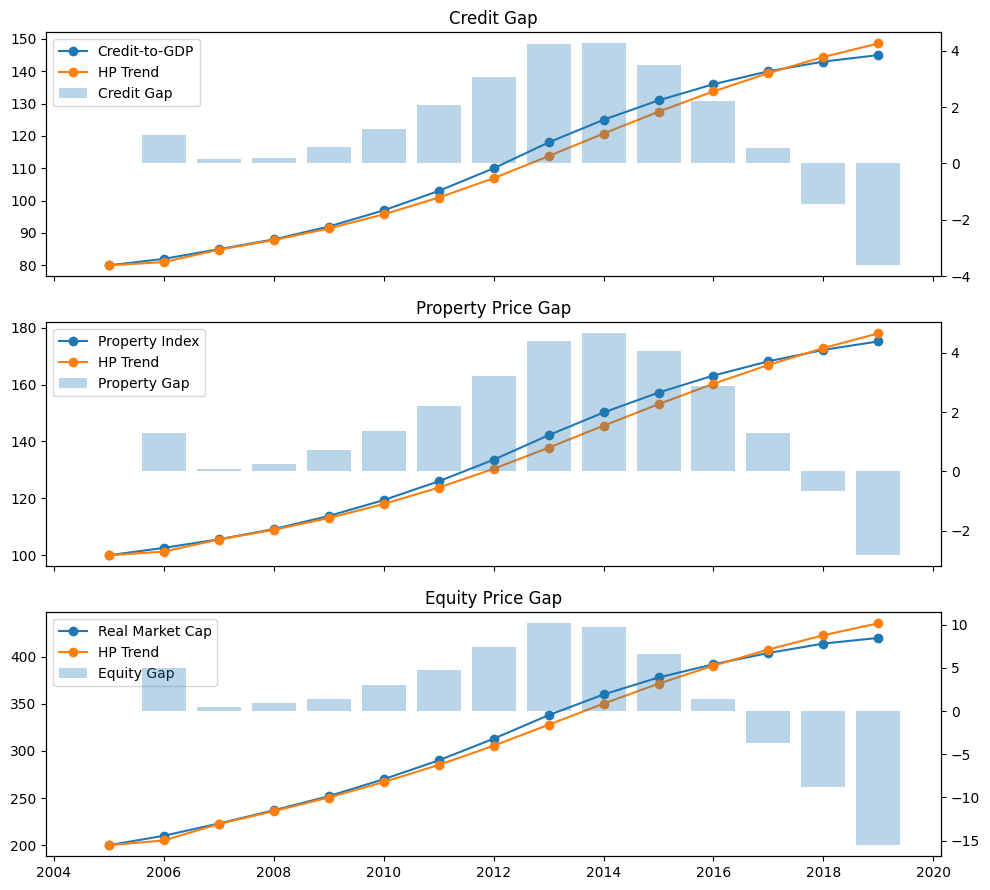

In [12]:
# ==========================================
# Plot raw series and trends
# ==========================================
fig, axes = plt.subplots(3, 1, figsize=(10, 9), sharex=True)

# --- Credit ---
ax1 = axes[0]
ax1.plot(years, credit_to_gdp, marker="o", label="Credit-to-GDP")
ax1.plot(years, cg_tr, marker="o", label="HP Trend")

ax1b = ax1.twinx()
ax1b.bar(years, cg, alpha=0.3, label="Credit Gap")

ax1.set_title("Credit Gap")

lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax1b.get_legend_handles_labels()
ax1.legend(lines + lines2, labels + labels2)

# --- Property ---
ax2 = axes[1]
ax2.plot(years, prop_index, marker="o", label="Property Index")
ax2.plot(years, pg_tr, marker="o", label="HP Trend")

ax2b = ax2.twinx()
ax2b.bar(years, pg, alpha=0.3, label="Property Gap")

ax2.set_title("Property Price Gap")

lines, labels = ax2.get_legend_handles_labels()
lines2, labels2 = ax2b.get_legend_handles_labels()
ax2.legend(lines + lines2, labels + labels2)

# --- Equity ---
ax3 = axes[2]
ax3.plot(years, real_mkt_cap, marker="o", label="Real Market Cap")
ax3.plot(years, eg_tr, marker="o", label="HP Trend")

ax3b = ax3.twinx()
ax3b.bar(years, eg, alpha=0.3, label="Equity Gap")

ax3.set_title("Equity Price Gap")

lines, labels = ax3.get_legend_handles_labels()
lines2, labels2 = ax3b.get_legend_handles_labels()
ax3.legend(lines + lines2, labels + labels2)

plt.tight_layout()
plt.show()

### Interpretation of Results

The results illustrate clearly how gap-based indicators behave relative to their long-run trends and how they signal the buildup and unwinding of financial imbalances.

From 2005 to around 2013–2014, all three gaps—credit, property, and equity—are **positive and increasing**. This indicates that the corresponding variables are persistently above their HP-filtered trends, which, in the context of the framework, reflects a **buildup phase of financial imbalances**. In particular, the credit gap rises steadily, while the property and equity gaps show even stronger deviations, consistent with the idea that rapid credit expansion and rising asset prices tend to reinforce each other.

The peak occurs roughly around 2013–2014, where the gaps are largest. This corresponds to the **“boom” phase** in the terminology of the paper: variables significantly exceed their long-run levels, suggesting potentially unsustainable conditions.

After this point, the gaps begin to decline and eventually turn **negative**. By 2017–2019, all three gaps are below zero, with the equity gap becoming strongly negative. This indicates that the variables have fallen **below their estimated trends**, which is consistent with the **“bust” or correction phase** following a buildup of imbalances.

The latest values (2019) reinforce this interpretation. The credit gap is moderately negative, the property gap is slightly negative, and the equity gap is strongly negative. This suggests that the system has moved from a state of excess (above-trend) to one of compression or adjustment (below-trend), with equity markets experiencing the largest correction relative to trend.

Overall, the synthetic example reproduces the key intuition of the framework: **large positive gaps signal the buildup of systemic risk**, while subsequent reversals toward negative gaps reflect the unwinding of those imbalances. This sets the stage for the next step, where such gap indicators would be used to generate signals and evaluate their ability to predict costly boom–bust cycles.

---

**The A.2 Framework: Construction of Gap-Based Indicators, how they are used**

The A.2 framework focuses on **constructing economically motivated indicators** designed to capture the buildup of systemic risk.

The central idea is that financial instability arises from the joint dynamics of **credit expansion and asset-price inflation**. To capture this, the framework defines three key indicators:
- the **credit gap** (credit-to-GDP relative to trend),
- the **equity-price gap** (real market capitalization relative to trend),
- the **property-price gap** (weighted real estate prices relative to trend).

Each indicator is constructed by applying a **one-sided Hodrick–Prescott filter** to estimate its long-run trend, and then computing the deviation (gap) from that trend. Positive gaps indicate that the variable is above its equilibrium level and may signal the buildup of financial imbalances.

Rather than relying on individual indicators, the framework emphasizes **joint signals**. A warning is issued when multiple indicators simultaneously exceed their respective thresholds, reflecting the idea that systemic risk emerges when imbalances reinforce each other across different dimensions of the economy.

Thresholds for these indicators are selected via grid search to optimize predictive performance, typically measured using criteria such as the noise-to-signal ratio or the true positive rate. The output of the framework is therefore a set of **indicator thresholds and joint signaling rules** that are intended to identify periods of heightened systemic vulnerability.

Overall, A.2 is a **model construction framework**: it defines how to build indicators and combine them into signals that may serve as early warnings of financial crises.

---

**How Signals Are Combined in A.2**

In the A.2 framework, signals are combined using **joint threshold conditions**. Each indicator is first converted into a binary signal based on whether it exceeds a chosen threshold. For example:
$$
S^{(c)}_t = \mathbf{1}\{\text{credit gap}_t > c_c\}, \quad
S^{(e)}_t = \mathbf{1}\{\text{equity gap}_t > c_e\}, \quad
S^{(p)}_t = \mathbf{1}\{\text{property gap}_t > c_p\}.
$$

A **joint signal** is then constructed by requiring that multiple conditions hold simultaneously. For instance:
$$
S_t = \mathbf{1}\{S^{(c)}_t = 1 \ \text{and} \ S^{(e)}_t = 1\}
= \mathbf{1}\{\text{credit gap}_t > c_c \ \text{and} \ \text{equity gap}_t > c_e\}.
$$

Similarly, one can define:
- credit + property:
$$
S_t = \mathbf{1}\{\text{credit gap}_t > c_c \ \text{and} \ \text{property gap}_t > c_p\},
$$
- equity + property, or even all three jointly.

The thresholds $(c_c, c_e, c_p)$ are chosen via grid search to optimize a performance criterion (e.g. minimize noise-to-signal ratio or maximize true positive rate). Each candidate combination of thresholds defines a different signaling rule.

The key idea is that **a signal is only issued when multiple indicators simultaneously indicate excess**, reflecting the view that systemic risk arises from the interaction of imbalances rather than from any single variable alone.

---

## Interpreting Gap Indicators and Example Decisions

Let us see how we can use the plot above for some example decision-making.

The three panels show the evolution of credit, property, and equity gaps relative to their HP-filtered trends. The key idea is to interpret **positive gaps as signs of buildup of financial imbalances** and **negative gaps as signs of unwinding or correction**.

### 1. Buildup Phase (≈ 2011–2014)
All three gaps are **positive and rising**, with the equity gap especially large.
- Interpretation: broad-based overheating driven by credit expansion and asset-price inflation.
- Example decision:  
  - Activate **countercyclical capital buffers**  
  - Tighten **loan-to-value (LTV)** or **debt-to-income (DTI)** limits  
  - Increase monitoring of leverage and speculative activity  

This is the regime where **joint signals** (credit + property/equity) would likely be triggered.


### 2. Peak / Warning Zone (≈ 2013–2015)
Gaps are near their **maximum levels**, particularly for equity and property.
- Interpretation: system is at **high risk of a boom turning into a bust**.
- Example decision:  
  - Maintain or further tighten macroprudential measures  
  - Consider additional policy tools (e.g., sectoral capital requirements)  
  - Prepare contingency plans for potential stress  

This is the **most critical window** for preemptive action.


### 3. Unwinding Phase (≈ 2015–2019)
Gaps decline and turn **negative**, especially for equity.
- Interpretation: correction phase; prior imbalances are being absorbed.
- Example decision:  
  - Gradually **release countercyclical buffers**  
  - Avoid over-tightening that could amplify the downturn  
  - Monitor for spillovers into the banking system  


### 4. Relative Importance Across Indicators
- **Equity gap**: most volatile ~ early signal of speculative excess and correction  
- **Property gap**: smoother ~ more persistent, tied to real economy  
- **Credit gap**: structural ~ key driver of systemic risk buildup  

Decisions are typically based on **joint behavior**, not any single gap.


### Bottom Line

Policy is not triggered by one variable alone, but by **co-movement**:
> When credit is high *and* asset prices are above trend ~ tighten  
> When gaps normalize or turn negative ~ ease cautiously  

This is exactly the logic behind A.2:

**systemic risk is identified through the interaction of multiple imbalances, not isolated signals.**

---

## A.3 Macroprudential Regulation

Macroprudential refers to a regulatory approach that focuses on safeguarding the stability of the financial system as a whole, rather than individual institutions, by monitoring and mitigating system-wide risks. This section explains how systemic-risk monitoring is connected to policy through a macroprudential framework. The core idea is that supervision should be calibrated from a **system-wide perspective**, not merely by aggregating the supervision of individual institutions. The motivation is that risk is partly **endogenous**: actions that appear rational at the level of a single firm can collectively generate instability for the financial system as a whole.

The section separates macroprudential risk into two dimensions. The first is the **time dimension**, which concerns how aggregate risk evolves over time and is mainly associated with **procyclicality**. The second is the **cross-sectional dimension**, which concerns how risk is distributed across institutions at a point in time and is mainly associated with **common exposures and interlinkages**. These two dimensions require different regulatory principles: countercyclical buffers for the time dimension, and institution-specific calibration of prudential tools for the cross-sectional dimension.

A key point is that different dimensions require different kinds of measures. In the time dimension, the ideal measure would be a reliable **leading indicator** of financial distress. In the cross-sectional dimension, the ideal measure would quantify each institution’s **contribution to systemic risk**. The text emphasizes that no single measure can do both well, and in particular that some market-based measures may give the **wrong signal** in the time dimension by making systemic risk look low precisely when it is high.

The section then turns to implementation. Borio argues that macroprudential policy should rely on rules as far as possible, because political economy pressures often lead policymakers to underreact during booms. At the same time, rules must remain simple and understandable, and some discretion must be preserved.

Finally, the section discusses Basel III as a practical example. Caruana argues that a **countercyclical capital buffer** could have reduced the severity of the crisis by requiring stronger capital positions during the credit boom. In this framework, the **credit-to-GDP ratio** serves as a system-wide reference variable for the buildup of the buffer. The section also notes that a buffer at its maximum should itself be treated as a signal for further action, such as tighter loan-to-value limits or limits on mortgage-interest deductions. Releasing the buffer late is less harmful than requiring it too late, because delayed accumulation leaves banks exposed during the boom, whereas delayed release merely constrains payouts after the crisis has started.

# **Grand Summary of Examples**

## Analyst Conclusions

**A.1 (Evaluation Framework)**  
Based on the results, because the indicator produces very low crisis detection (tp ≈ 10%), many false alarms (B = 43), and a loss worse than the trivial benchmark, it is not reliable; therefore, using it would lead to **mis-timed policy actions**—either tightening capital requirements and credit conditions unnecessarily during normal periods or failing to act before actual crises—both of which carry significant economic costs.

**A.2 (Indicator Construction Framework)**  
Based on the results, because credit, property, and equity gaps rise jointly and significantly above trend before declining, they signal a coordinated buildup of financial imbalances; therefore, the appropriate decision is to **tighten macroprudential policies** (e.g., raise countercyclical capital buffers, impose stricter lending standards) during the expansion phase and **gradually relax them** during the correction phase to avoid amplifying the downturn.

---

**Additional Remarks**

**A.1 (Evaluation Framework)**  
From a risk-assessment perspective, A.1 tells us whether a given warning signal is actually worth trusting. It forces us to quantify how often we would miss crises versus trigger false alarms, and to compare that performance against doing nothing or always acting. In our example, the signal fails this test, meaning we would not rely on it for policy or risk decisions.

**A.2 (Indicator Construction Framework)**  
From a risk-assessment perspective, A.2 tells us where systemic risk is building up by tracking credit and asset-price gaps. The joint elevation of these gaps signals a regime of increasing vulnerability, prompting preemptive tightening, while their decline signals unwinding and calls for caution or easing. In our example, the coordinated rise and fall of the gaps provides a clear narrative of buildup, peak risk, and subsequent correction.

**A.1 Example**  
The A.1 example shows how a given signaling rule is evaluated using a loss function that balances missed crises and false alarms. In our synthetic case, the indicator fails to outperform trivial strategies, illustrating that not all seemingly reasonable signals are useful. The framework therefore serves as a disciplined way to test whether a signal adds real predictive value.

**A.2 Example**  
The A.2 example constructs credit, property, and equity gaps and shows how their joint behavior reflects the buildup and unwinding of financial imbalances. Individually, these gaps indicate deviations from trend, but meaningful signals arise when multiple gaps are simultaneously elevated. This demonstrates that systemic risk is better captured through the interaction of indicators rather than any single variable alone.